# Seq2Seq 모델 Q&A Chatbot 구현

1. Qna 데이터셋을 찾아서 처리해서 준비한다. (전처리 전반)
2. Encoder, Decoder, Seq2Seq(Encoder+Decoder) 모델을 만든다.
3. 1에서 준비한 데이터로 2에서 만든 모델을 학습시킨다.
4. Chatbot을 만든다. (모델 추론 + While문)

### 1. 데이터 로드

In [134]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

# 챗봇 데이터 사용
df = pd.read_csv('https://raw.githubusercontent.com/songys/Chatbot_data/refs/heads/master/ChatbotData.csv')
df = df[['Q', 'A']]
df

,Q,A
0,12시 땡!,하루가 또 가네요.
1,1지망 학교 떨어졌어,위로해 드립니다.
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.
4,PPL 심하네,눈살이 찌푸려지죠.
...,...,...
11818,훔쳐보는 것도 눈치 보임.,티가 나니까 눈치가 보이는 거죠!
11819,훔쳐보는 것도 눈치 보임.,훔쳐보는 거 티나나봐요.
11820,흑기사 해주는 짝남.,설렜겠어요.
11821,힘든 연애 좋은 연애라는게 무슨 차이일까?,잘 헤어질 수 있는 사이 여부인 거 같아요.


In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Q       11823 non-null  str  
 1   A       11823 non-null  str  
dtypes: str(2)
memory usage: 996.0 KB


### 2. 학습 데이터 준비

In [68]:
Q_inputs = []
A_inputs = []
A_targets = []

for question, answer in df.values:
    answer_input = '<sos> ' + answer
    answer_target = answer + ' <eos>'

    Q_inputs.append(question)
    A_inputs.append(answer_input)
    A_targets.append(answer_target)

In [69]:
print(Q_inputs[5000])
print(A_inputs[5000])
print(A_targets[5000])

학원폭력 짜증나
<sos> 학교 폭력은 범죄에요.
학교 폭력은 범죄에요. <eos>


In [70]:
# 전역변수 선언
BATCH_SIZE = 32
MAX_VOCAB_SIZE = 8000
EMBEDDING_DIM = 64
LATENT_DIM = 128

### 3. 데이터 전처리

##### 토큰화

In [71]:
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='')
tokenizer.fit_on_texts(Q_inputs + A_inputs + A_targets)

Q_input_seqs = tokenizer.texts_to_sequences(Q_inputs)
A_input_seqs = tokenizer.texts_to_sequences(A_inputs)
A_target_seqs = tokenizer.texts_to_sequences(A_targets)

num_words = len(tokenizer.word_index) + 1
Q_max_len = max(len(s) for s in Q_input_seqs)
A_max_len = max(len(s) for s in A_input_seqs)

print(f'{num_words = }')
print(f'{Q_max_len = }')
print(f'{A_max_len = }')

num_words = 21800
Q_max_len = 12
A_max_len = 22


##### 패딩

In [72]:
encoder_inputs = pad_sequences(Q_input_seqs, maxlen=Q_max_len, padding='pre')
decoder_inputs = pad_sequences(A_input_seqs, maxlen=A_max_len, padding='post')
decoder_targets = pad_sequences(A_target_seqs, maxlen=A_max_len, padding='post')

print(encoder_inputs.shape)
print(decoder_inputs.shape)
print(decoder_targets.shape)

print(encoder_inputs[1000])
print([tokenizer.index_word[s] for s in encoder_inputs[1000] if s != 0])
print(decoder_inputs[1000])
print([tokenizer.index_word[s] for s in decoder_inputs[1000] if s != 0])
print(decoder_targets[1000])
print([tokenizer.index_word[s] for s in decoder_targets[1000] if s != 0])

(11823, 12)
(11823, 22)
(11823, 22)
[   0    0    0    0    0    0    0 2184   52   12  253  157]
['노래방', '걸', '거', '같은데', '뭐']
[   1 1817 5131    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
['<sos>', '달달한', '노래요.']
[1817 5131    2    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0]
['달달한', '노래요.', '<eos>']


##### 데이터 로더 설정

In [73]:
class NMTDataset(Dataset):
  def __init__(self, encoder_inputs, decoder_inputs, decoder_targets):
    super().__init__()
    self.encoder_inputs = encoder_inputs
    self.decoder_inputs = decoder_inputs
    self.decoder_targets = decoder_targets

  def __len__(self):
    return len(self.encoder_inputs)

  def __getitem__(self, index):
    return (
        torch.tensor(self.encoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_inputs[index], dtype=torch.long),
        torch.tensor(self.decoder_targets[index], dtype=torch.long),
    )

In [74]:
train_index, val_index = train_test_split(range(len(encoder_inputs)), random_state=0)
print(len(train_index), len(val_index))

train_dataset = NMTDataset(
    encoder_inputs[train_index],
    decoder_inputs[train_index],
    decoder_targets[train_index]
)
val_dataset = NMTDataset(
    encoder_inputs[val_index],
    decoder_inputs[val_index],
    decoder_targets[val_index]
)

8867 2956


In [75]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### 4. 모델 준비

##### 인코더

In [76]:
class Encoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim, embedding_matrix=None):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    if embedding_matrix is not None:
      self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))
    self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)

  def forward(self, X):
    X = self.embedding(X)
    output, (h_s, c_s) = self.lstm(X)
    return h_s, c_s

##### 디코더

In [77]:
class Decoder(nn.Module):
  def __init__(self, vocab_size, embedding_dim, latent_dim):
    super().__init__()
    self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
    self.lstm = nn.LSTM(embedding_dim, latent_dim, batch_first=True)
    self.fc = nn.Linear(latent_dim, vocab_size)

  def forward(self, X, hidden, cell):
    X = self.embedding(X)
    output, (h_s, c_s) = self.lstm(X, (hidden, cell))
    logits = self.fc(output)
    return logits, h_s, c_s

##### Seq2Seq

In [78]:
class Seq2Seq(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, source, target):
    h_s, c_s = self.encoder(source)
    output, h_s, c_s = self.decoder(target, h_s, c_s)
    return output

In [79]:
encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM, embedding_matrix=None)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)

model = Seq2Seq(encoder, decoder)

In [80]:
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(21800, 64, padding_idx=0)
    (lstm): LSTM(64, 128, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(21800, 64, padding_idx=0)
    (lstm): LSTM(64, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=21800, bias=True)
  )
)

### 5. 모델 학습

In [81]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

encoder = Encoder(num_words, EMBEDDING_DIM, LATENT_DIM, embedding_matrix=None)
decoder = Decoder(num_words, EMBEDDING_DIM, LATENT_DIM)
model = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.AdamW(model.parameters(), lr=0.001)

epochs = 20

train_losses, train_accs, val_losses, val_accs = [], [], [], []

for epoch in range(epochs):
  model.train()
  train_loss, train_correct, train_tokens = 0, 0, 0

  for enc_inputs, dec_inputs, dec_targets in train_loader:
    enc_inputs = enc_inputs.to(device)
    dec_inputs = dec_inputs.to(device)
    dec_targets = dec_targets.to(device)

    optimizer.zero_grad()

    # teacher forcing
    output = model(enc_inputs, dec_inputs)
    output = output.view(-1, output.size(-1))
    dec_targets = dec_targets.view(-1)

    loss = criterion(output, dec_targets)
    loss.backward()
    optimizer.step()

    preds = output.argmax(dim=-1)
    train_loss += loss.detach().cpu().item()
    mask = dec_targets != 0
    correct = (preds == dec_targets) & mask
    train_correct += correct.sum().detach().cpu().item()
    train_tokens += mask.sum().detach().cpu().item()

  train_loss /= len(train_loader)
  train_acc = train_correct / train_tokens
  train_losses.append(train_loss)
  train_accs.append(train_acc)

  model.eval()
  with torch.no_grad():
    val_loss, val_correct, val_tokens = 0, 0, 0

    for enc_inputs, dec_inputs, dec_targets in val_loader:
      enc_inputs = enc_inputs.to(device)
      dec_inputs = dec_inputs.to(device)
      dec_targets = dec_targets.to(device)

      output = model(enc_inputs, dec_inputs)
      output = output.view(-1, output.size(-1))
      dec_targets = dec_targets.view(-1)

      loss = criterion(output, dec_targets)

      preds = output.argmax(dim=-1)
      val_loss += loss.detach().cpu().item()
      mask = dec_targets != 0
      correct = (preds == dec_targets) & mask
      val_correct += correct.sum().detach().cpu().item()
      val_tokens += mask.sum().detach().cpu().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_tokens
    val_losses.append(val_loss)
    val_accs.append(val_acc)

  print(f'Epoch {epoch+1}/{epochs} TrainLoss={train_loss:.4f} TrainAcc={train_acc:.4f} ValLoss={val_loss:.4f} ValAcc={val_acc:.4f}')

Epoch 1/20 TrainLoss=7.0052 TrainAcc=0.2171 ValLoss=6.4230 ValAcc=0.2287
Epoch 2/20 TrainLoss=6.0884 TrainAcc=0.2366 ValLoss=6.2134 ValAcc=0.2464
Epoch 3/20 TrainLoss=5.8159 TrainAcc=0.2472 ValLoss=6.0574 ValAcc=0.2495
Epoch 4/20 TrainLoss=5.5530 TrainAcc=0.2513 ValLoss=5.9114 ValAcc=0.2541
Epoch 5/20 TrainLoss=5.2511 TrainAcc=0.2592 ValLoss=5.7614 ValAcc=0.2599
Epoch 6/20 TrainLoss=4.9262 TrainAcc=0.2752 ValLoss=5.5962 ValAcc=0.2701
Epoch 7/20 TrainLoss=4.5872 TrainAcc=0.3001 ValLoss=5.4497 ValAcc=0.2860
Epoch 8/20 TrainLoss=4.2606 TrainAcc=0.3356 ValLoss=5.3072 ValAcc=0.3007
Epoch 9/20 TrainLoss=3.9406 TrainAcc=0.3803 ValLoss=5.1897 ValAcc=0.3151
Epoch 10/20 TrainLoss=3.6496 TrainAcc=0.4214 ValLoss=5.1084 ValAcc=0.3263
Epoch 11/20 TrainLoss=3.3946 TrainAcc=0.4548 ValLoss=4.9991 ValAcc=0.3456
Epoch 12/20 TrainLoss=3.1755 TrainAcc=0.4864 ValLoss=4.9482 ValAcc=0.3625
Epoch 13/20 TrainLoss=2.9765 TrainAcc=0.5149 ValLoss=4.8840 ValAcc=0.3786
Epoch 14/20 TrainLoss=2.8006 TrainAcc=0.5405 Va

In [82]:
torch.save(model, 'seq2seq_teacher_forcing.pth')

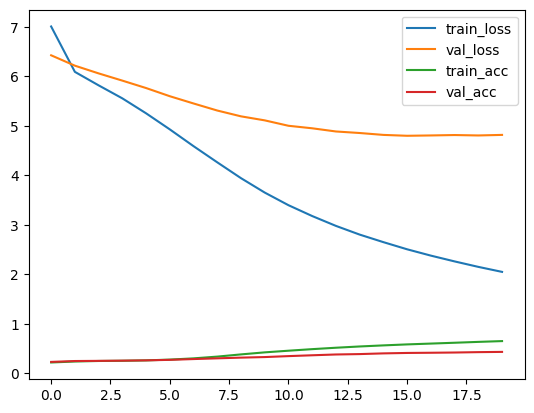

In [85]:
pd.DataFrame({
    'train_loss': train_losses,
    'val_loss': val_losses,
    'train_acc': train_accs,
    'val_acc': val_accs,
}).plot()
plt.show()

In [86]:
model = torch.load('seq2seq_teacher_forcing.pth', weights_only=False)
model

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(21800, 64, padding_idx=0)
    (lstm): LSTM(64, 128, batch_first=True)
  )
  (decoder): Decoder(
    (embedding): Embedding(21800, 64, padding_idx=0)
    (lstm): LSTM(64, 128, batch_first=True)
    (fc): Linear(in_features=128, out_features=21800, bias=True)
  )
)

### 6. 모델 추론

In [87]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def translate(input_seq, model, tokenizer, max_len=A_max_len, device=device):
  model = model.to(device)
  model.eval()
  encoder = model.encoder
  decoder = model.decoder

  input_seq = torch.tensor(input_seq, dtype=torch.long).to(device)

  # Encoder 처리
  with torch.no_grad():
    hidden, cell = encoder(input_seq)

  # Decoder 출력(Auto Regressive)
  sos_index = tokenizer.word_index['<sos>']
  eos_index = tokenizer.word_index['<eos>']

  output_sentences = []

  target_seq = torch.tensor([[sos_index]], dtype=torch.long).to(device)

  with torch.no_grad():
    for _ in range(max_len):
      output, hidden, cell = decoder(target_seq, hidden, cell)  # (batch_size, seq_len, vocab_size)
      proba = output.squeeze(1).softmax(dim=-1)                 # (batch_size, vocab_size)
      pred = proba.argmax(dim=-1).detach().cpu().item()

      if pred == eos_index:
        break

      if pred > 0:
        word = tokenizer.index_word[pred]
        output_sentences.append(word)

      target_seq = torch.tensor([[pred]], dtype=torch.long).to(device)

  return ' '.join(output_sentences)

In [132]:
for _ in range(5):
  index = np.random.choice(len(Q_inputs))
  input_seq = encoder_inputs[index:index+1]
  output = translate(input_seq, model, tokenizer)

  print(f'질문: {Q_inputs[index]}')
  print(f'답변: {A_inputs[index]}')
  print(f'모델 추론 답변: {output}')
  print()

질문: 스터디 카페 왔어
답변: <sos> 공부하러 왔나봐요.
모델 추론 답변: 저는 둘이 싶어요.

질문: 남자친구가 좋은데 눈치가 없어.
답변: <sos> 눈치는 선천적인 거예요.
모델 추론 답변: 좋은 사람 만날 수 있을 거예요.

질문: 조용히 있고 싶어
답변: <sos> 저 나가면 될까요?
모델 추론 답변: 저도 궁금하네요.

질문: 나이 차이 많이 나는 여자 어때?
답변: <sos> 사랑에 나이는 중요하지 않아요.
모델 추론 답변: 믿음이 흔들리고 마음을

질문: 결국 이별 종지부를 찍었네.
답변: <sos> 좋은 시작이 되길 기원할게요.
모델 추론 답변: 좋은 생각이에요.



In [133]:
def chatbot(question, tokenizer=tokenizer):
  input_seq = tokenizer.texts_to_sequences([question])
  input_seq = pad_sequences(input_seq, maxlen=Q_max_len, padding='pre')
  return translate(input_seq, model, tokenizer)

question_texts = [
    '배고파',
    '졸리다',
    '저녁 뭐 먹을까요?',
    '집 가고 싶어요',
    '오늘은 수요일이에요!'
]

for question in question_texts:
  answer = chatbot(question)
  print(f'{question} => {answer}')

배고파 => 너무 자책하지 마세요.
졸리다 => 저도 보고 싶어요.
저녁 뭐 먹을까요? => 맛있는 거 드세요.
집 가고 싶어요 => 저는 위로해드리는 로봇이에요.
오늘은 수요일이에요! => 저도 궁금하네요.
